# [4.0] DESI x DESI Legacy Crossmatch

In this notebook, we will:
- **crossmatch** the DESI Main Survey (dark program) DR1 with the DESI Legacy survey hosted on [data.lsdb.io](data.lsdb.io)
- **save** the resulting catalog to the NERSC Community File System (CFS)
- discuss **performance and resource use** of the crossmatch

## Set up

In [ ]:
import os
import time
from pathlib import Path

import lsdb
import matplotlib.pyplot as plt
import pandas as pd
from dask.distributed import Client, performance_report
from hats.io.validation import is_valid_catalog


# Set our output directory

users_dir = Path("/global/cfs/cdirs/cosmo/users/")
target_user_dir = users_dir / "olynn"

In [3]:
# Make a dask client

client = Client(
    n_workers=32,
    threads_per_worker=2,
    memory_limit="14GB",   # 32 × 14 = 448 GB, well within 487 GB
)

In [4]:
# Set up dashboard port forwarding instructions for the user. 
# Note that the compute node hostname is needed to set up the ssh tunnel correctly.

import socket

username = os.getenv("USER")
current_compute_node = socket.gethostname()

print(f"1. In a local shell, run: ssh -L 8787:{current_compute_node}:8787 {username}@perlmutter.nersc.gov")
print("2. Enter password + OTP")
print(f"3. See Dask Dashboard in browser (on your local machine) at: http://localhost:8787/status")

1. In a local shell, run: ssh -L 8787:nid004230:8787 olynn@perlmutter.nersc.gov
2. Enter password + OTP
3. See Dask Dashboard in browser (on your local machine) at: http://localhost:8787/status


## Load catalogs

In [5]:
desi_cat = lsdb.open_catalog("/global/cfs/cdirs/cosmo/users/olynn/desi-dr1-main-dark")
desi_cat

,TARGETID,TARGET_RA,TARGET_DEC,Z,ZERR,spectra_b,spectra_r,spectra_z
npartitions=5769,,,,,,,,
"Order: 6, Pixel: 0",int64[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],double[pyarrow],"nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv...","nested<wavelength: [double], flux: [float], iv..."
"Order: 6, Pixel: 1",...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12286",...,...,...,...,...,...,...,...
"Order: 5, Pixel: 12287",...,...,...,...,...,...,...,...


(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of desi-dr1-main-dark'}>)

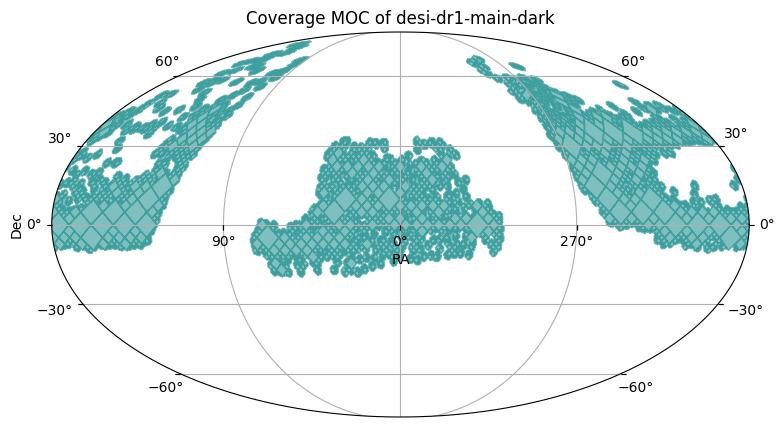

In [6]:
desi_cat.plot_coverage()

In [7]:
desi_legacy_cat = lsdb.open_catalog(
    "https://data.lsdb.io/hats/legacysurvey_dr10.1",
    #columns=["source_id", "ra", "dec"]
)
desi_legacy_cat

,RELEASE,BRICKID,BRICKNAME,OBJID,TYPE,RA,DEC,RA_IVAR,DEC_IVAR,DCHISQ,EBV,FLUX_G,FLUX_R,FLUX_I,FLUX_Z,FLUX_W1,FLUX_W2,FLUX_W3,FLUX_W4,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_I,FLUX_IVAR_Z,FLUX_IVAR_W1,FLUX_IVAR_W2,FLUX_IVAR_W3,FLUX_IVAR_W4,MW_TRANSMISSION_G,MW_TRANSMISSION_R,MW_TRANSMISSION_I,MW_TRANSMISSION_Z,MW_TRANSMISSION_W1,MW_TRANSMISSION_W2,MW_TRANSMISSION_W3,MW_TRANSMISSION_W4,NOBS_G,NOBS_R,NOBS_I,NOBS_Z,NOBS_W1,NOBS_W2,NOBS_W3,NOBS_W4,RCHISQ_G,RCHISQ_R,RCHISQ_I,RCHISQ_Z,RCHISQ_W1,RCHISQ_W2,RCHISQ_W3,RCHISQ_W4,FRACFLUX_G,FRACFLUX_R,FRACFLUX_I,FRACFLUX_Z,FRACFLUX_W1,FRACFLUX_W2,FRACFLUX_W3,FRACFLUX_W4,FRACMASKED_G,FRACMASKED_R,FRACMASKED_I,FRACMASKED_Z,FRACIN_G,FRACIN_R,FRACIN_I,FRACIN_Z,ANYMASK_G,ANYMASK_R,ANYMASK_I,ANYMASK_Z,ALLMASK_G,ALLMASK_R,ALLMASK_I,ALLMASK_Z,WISEMASK_W1,WISEMASK_W2,PSFSIZE_G,PSFSIZE_R,PSFSIZE_I,PSFSIZE_Z,PSFDEPTH_G,PSFDEPTH_R,PSFDEPTH_I,PSFDEPTH_Z,GALDEPTH_G,GALDEPTH_R,GALDEPTH_I,GALDEPTH_Z,PSFDEPTH_W1,PSFDEPTH_W2,WISE_COADD_ID,SHAPE_R,SHAPE_R_IVAR,SHAPE_E1,SHAPE_E1_IVAR,SHAPE_E2,SHAPE_E2_IVAR,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_I,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_I,FIBERTOTFLUX_Z,REF_CAT,REF_ID,REF_EPOCH,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_G_MEAN_FLUX_OVER_ERROR,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_BP_MEAN_FLUX_OVER_ERROR,GAIA_PHOT_RP_MEAN_MAG,GAIA_PHOT_RP_MEAN_FLUX_OVER_ERROR,GAIA_ASTROMETRIC_EXCESS_NOISE,GAIA_DUPLICATED_SOURCE,GAIA_PHOT_BP_RP_EXCESS_FACTOR,GAIA_ASTROMETRIC_SIGMA5D_MAX,GAIA_ASTROMETRIC_PARAMS_SOLVED,PARALLAX,PARALLAX_IVAR,PMRA,PMRA_IVAR,PMDEC,PMDEC_IVAR,MASKBITS,FITBITS,SERSIC,SERSIC_IVAR
npartitions=64179,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"Order: 6, Pixel: 0",int16[pyarrow],int32[pyarrow],string[pyarrow],int32[pyarrow],string[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],float[pyarrow],fixed_size_list<element: float>[5][pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],int16[pyarrow],uint8[pyarrow],uint8[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],string[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],string[pyarrow],int64[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],bool[pyarrow],float[pyarrow],float[pyarrow],uint8[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],float[pyarrow],int32[pyarrow],int16[pyarrow],float[pyarrow],float[pyarrow]
"Order: 6, Pixel: 1",...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

(<Figure size 900x500 with 1 Axes>,
 <WCSAxes: title={'center': 'Coverage MOC of legacysurvey_dr10.1'}>)

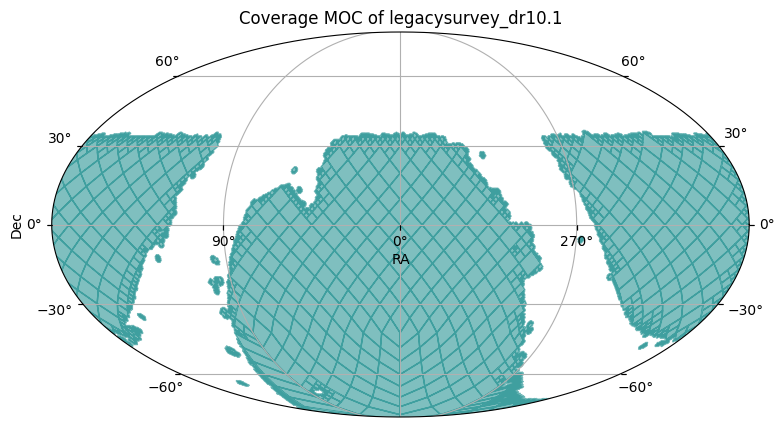

In [8]:
desi_legacy_cat.plot_coverage()

## Do crossmatch

In [ ]:
desi_dr1_x_desi_legacy = desi_cat.crossmatch(desi_legacy_cat, suffix_method="overlapping_columns", suffixes=("_dr1", "_legacy"))

In [ ]:
start = time.perf_counter()

catalog_name = "desi_dr1_x_desi_legacy"
with performance_report(filename="crossmatch_report.html"):
    desi_dr1_x_desi_legacy.write_catalog(
        base_catalog_path=target_user_dir,
        catalog_name=catalog_name,
    )

elapsed = time.perf_counter() - start

In [ ]:
print(f"Crossmatch took {int(elapsed/60):d}m {elapsed%60:.1f}s")

## Verify crossmatched catalog

In [ ]:
# Check that the catalog was written correctly

output_catalog = target_user_dir / catalog_name

is_valid_catalog(output_catalog, verbose=True, fail_fast=False, strict=True)

In [ ]:
# Calculate size of the catalog on disk

! du -sh $output_catalog

In [ ]:
# Open catalog

desi_dr1_x_desi_legacy_cat = lsdb.open_catalog(output_catalog)
desi_dr1_x_desi_legacy_cat

In [ ]:
# Plot coverage

desi_dr1_x_desi_legacy_cat.plot_coverage()

In [ ]:
# See the first few rows

df = desi_dr1_x_desi_legacy_cat.head(5)
df

In [ ]:
# Plot spectra of a row

target_idx = 2

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)
colors = ["steelblue", "plum"]

# Iterate over the three cameras and plot the spectra for the target at target_idx.
for ax, cam in zip(axes, ["b", "r", "z"]):
    # Get the spectrum.
    spec = df[f"spectra_{cam}"].iloc[target_idx]

    # Plot flux on the primary y-axis.
    ax.plot(spec["wavelength"], spec["flux"], lw=0.8, color=colors[0], label="flux")
    
    # Plot ivar on the secondary y-axis.
    ax_twin = ax.twinx()
    ax_twin.plot(spec["wavelength"], spec["ivar"], lw=0.5, color=colors[1], alpha=0.5, label="ivar")
    ax_twin.set_ylabel("ivar", color=colors[1])
    ax_twin.tick_params(axis="y", labelcolor=colors[1])
    
    # Set labels and title for the primary y-axis.
    ax.set_ylabel("Flux (nanomaggies)") # https://desidatamodel.readthedocs.io/en/latest/DESI_SPECTRO_DATA/NIGHT/EXPID/fibermap-EXPID.html#required-data-table-columns:~:text=nanomaggies
    ax.set_title(f"Camera {cam.upper()}")
    ax.legend(loc="upper left")

# Set x-axis label and overall figure title.
axes[-1].set_xlabel("Wavelength (Å)")
fig.suptitle(f"TARGETID={df.index[target_idx]}(Z={df['Z'].iloc[target_idx]:.4f})")
plt.tight_layout()
plt.show()

## Performance Analysis

In [ ]:
# Generate markdown tables for the Dask dashboard reports

from dask_report_utils import client_table, metrics_table

print(client_table("crossmatch_report.html", threads_per_worker=2, memory_limit_per_worker="14 GB"), "\n")
print(metrics_table("crossmatch_report.html"), "\n")

### 1. Setup

### 2. Wall Time

### 3. Dask Performance Report

### 4. Recommendations